In [15]:
import os
import sys
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score,
    matthews_corrcoef, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import pickle
import warnings
warnings.filterwarnings('ignore')

# ===== Set Paths =====
BASE_DIR = Path('/mnt/storage/SLIIT/research/R26-IT-036')
DATA_DIR = BASE_DIR / 'data/Stress header/processed'
MODELS_DIR = BASE_DIR / 'models/c3_text_stressor_distortion/Stress header'
RESULTS_DIR = BASE_DIR / 'reports/c3_text_stressor_distortion/Stress header/evaluation/metrics'
PLOTS_DIR = RESULTS_DIR / 'plots'
PLOTS_DIR.mkdir(exist_ok=True, parents=True)

sys.path.insert(0, str(BASE_DIR / 'ai_components/c3_text_stressor_distortion/Stress header/train'))


from config import Config
from model import DualHeadStressModel
from utils import compute_metrics, compute_head1b_metrics

print(f" Base dir: {BASE_DIR}")
print(f" Data dir: {DATA_DIR}")
print(f" Models dir: {MODELS_DIR}")
print(f" Results dir: {RESULTS_DIR}")

 Base dir: /mnt/storage/SLIIT/research/R26-IT-036
 Data dir: /mnt/storage/SLIIT/research/R26-IT-036/data/Stress header/processed
 Models dir: /mnt/storage/SLIIT/research/R26-IT-036/models/c3_text_stressor_distortion/Stress header
 Results dir: /mnt/storage/SLIIT/research/R26-IT-036/reports/c3_text_stressor_distortion/Stress header/evaluation/metrics


In [16]:
BASE_DIR = Path('/mnt/storage/SLIIT/research/R26-IT-036')
DATA_DIR = BASE_DIR / 'data/Stress header/processed'
MODELS_DIR = BASE_DIR / 'models/c3_text_stressor_distortion/Stress header'
RESULTS_DIR = BASE_DIR / 'reports/c3_text_stressor_distortion/Stress header/evaluation/metrics'
PLOTS_DIR = RESULTS_DIR / 'plots'
PLOTS_DIR.mkdir(exist_ok=True, parents=True)

sys.path.insert(0, str(BASE_DIR / 'ai_components/c3_text_stressor_distortion/Stress header/train'))

In [17]:
# Load Transformer Models 
print("\n" + "="*70)
print("LOADING TRANSFORMER MODELS")
print("="*70)

from transformers import AutoTokenizer

# Model configurations
model_configs = {
    'BERT': {
        'hf_id': 'bert-base-uncased',
        'model_path': MODELS_DIR / 'BERT_best.pt',
        'text_col': 'text_for_bert',
    },
    'MentalBERT': {
        'hf_id': 'mental/mental-bert-base-uncased',
        'model_path': MODELS_DIR / 'MentalBERT_best.pt',
        'text_col': 'text_for_mentalbert',
    },
    'DeBERTa-v3': {
        'hf_id': 'microsoft/deberta-v3-base',
        'model_path': MODELS_DIR / 'DeBERTa-v3_best.pt',
        'text_col': 'text_for_deberta',
    },
}

# Load metadata for max_len
with open(DATA_DIR / 'metadata.json', 'r') as f:
    metadata = json.load(f)
max_len = metadata.get('max_len', Config.BASE_HYPERPARAMS['MAX_LEN'])

transformer_models = {}
for model_name, config in model_configs.items():
    try:
        print(f"\n→ Loading {model_name}...")
        
        # Load tokenizer
        tokenizer = AutoTokenizer.from_pretrained(config['hf_id'])
        
        # Load model
        model = DualHeadStressModel(
            hf_id=config['hf_id'],
            num_subreddit_labels=10,
            num_binary_labels=2,
            dropout=0.3,
            head_dropout=0.1,
            intermediate=256
        )
        
        # Load weights
        state_dict = torch.load(config['model_path'], map_location='cpu')
        model.load_state_dict(state_dict)
        model = model.to(Config.DEVICE).eval()
        
        transformer_models[model_name] = {
            'model': model,
            'tokenizer': tokenizer,
            'text_col': config['text_col'],
            'path': config['model_path'],
        }
        print(f"   {model_name} loaded successfully")
    except Exception as e:
        print(f"   Error loading {model_name}: {e}")

print(f"\n Loaded {len(transformer_models)} transformer models")


LOADING TRANSFORMER MODELS

→ Loading BERT...
   BERT loaded successfully

→ Loading MentalBERT...


Some weights of BertModel were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   MentalBERT loaded successfully

→ Loading DeBERTa-v3...
   DeBERTa-v3 loaded successfully

 Loaded 3 transformer models


In [18]:
# Load Baseline Models 
from sklearn.feature_extraction.text import TfidfVectorizer

baseline_models = {}
baseline_configs = {
    'LR': MODELS_DIR / 'baseline_LR.pkl',
    'SVM': MODELS_DIR / 'baseline_SVM.pkl',
}

for model_name, model_path in baseline_configs.items():
    try:
        print(f"\n→ Loading {model_name}...")
        with open(model_path, 'rb') as f:
            model_dict = pickle.load(f)
        
        baseline_models[model_name] = {
            'model': model_dict.get('model'),
            'vectorizer': model_dict.get('vectorizer'),
            'path': model_path,
        }
        print(f"   {model_name} loaded successfully")
    except Exception as e:
        print(f"   Error loading {model_name}: {e}")

print(f"\n Loaded {len(baseline_models)} baseline models")


→ Loading LR...
   LR loaded successfully

→ Loading SVM...
   SVM loaded successfully

 Loaded 2 baseline models


In [19]:
# Evaluation Functions 

def evaluate_transformer(model_info, test_df, batch_size=32):
    """Evaluate transformer model on test set."""
    model = model_info['model']
    tokenizer = model_info['tokenizer']
    text_col = model_info['text_col']
    
    preds_1a, preds_1b = [], []
    probs_1a, labels_1a, labels_1b = [], [], []
    
    model.eval()
    
    with torch.no_grad():
        for i in range(0, len(test_df), batch_size):
            batch_df = test_df.iloc[i:i+batch_size]
            
            # Tokenize
            texts = batch_df[text_col].fillna('').tolist()
            encoded = tokenizer(
                texts,
                max_length=max_len,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )
            
            input_ids = encoded['input_ids'].to(Config.DEVICE)
            attention_mask = encoded['attention_mask'].to(Config.DEVICE)
            
            # Forward pass
            logits_1a, logits_1b = model(input_ids, attention_mask)
            
            # Collect predictions
            preds_1a.extend(logits_1a.argmax(dim=1).cpu().numpy())
            preds_1b.extend(logits_1b.argmax(dim=1).cpu().numpy())
            probs_1a.extend(torch.softmax(logits_1a, dim=1)[:, 1].cpu().numpy())
            labels_1a.extend(batch_df['label'].tolist())
            labels_1b.extend(batch_df['subreddit_label'].tolist())
    
    return {
        'preds_1a': np.array(preds_1a),
        'preds_1b': np.array(preds_1b),
        'probs_1a': np.array(probs_1a),
        'labels_1a': np.array(labels_1a),
        'labels_1b': np.array(labels_1b),
    }

def evaluate_baseline(baseline_info, test_df):
    """Evaluate baseline model on test set."""
    model = baseline_info['model']
    vectorizer = baseline_info['vectorizer']
    
    texts = test_df['text'].fillna('').tolist()
    X = vectorizer.transform(texts)
    
    preds = model.predict(X)
    
    # Get probabilities
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X)[:, 1]
    else:
        probs = model.decision_function(X)
    
    return {
        'preds': preds,
        'probs': probs,
        'labels': test_df['label'].values,
    }

def compute_all_metrics(preds, labels, probs=None):
    """Compute comprehensive evaluation metrics."""
    metrics = {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, average='binary', zero_division=0),
        'recall': recall_score(labels, preds, average='binary', zero_division=0),
        'f1': f1_score(labels, preds, average='binary', zero_division=0),
        'mcc': matthews_corrcoef(labels, preds),
    }
    
    if probs is not None:
        try:
            metrics['roc_auc'] = roc_auc_score(labels, probs)
        except:
            metrics['roc_auc'] = np.nan
    
    return metrics



In [20]:
# Evaluate Transformer Models 

if 'test_df' not in globals():
    test_df = pd.read_csv(DATA_DIR / 'dreaddit_test.csv')
    print(f"Loaded test_df: {len(test_df)} rows from {DATA_DIR / 'dreaddit_test.csv'}")


transformer_results = {}

for model_name, model_info in transformer_models.items():
    print(f"\n→ Evaluating {model_name}...")
    
    results = evaluate_transformer(model_info, test_df, batch_size=32)
    
    # Compute metrics for stress detection (Head 1A)
    metrics_1a = compute_all_metrics(
        results['preds_1a'], 
        results['labels_1a'],
        results['probs_1a']
    )
    
    # Compute metrics for subreddit classification (Head 1B)
    metrics_1b = compute_head1b_metrics(
        results['labels_1b'],
        results['preds_1b']
    )
    
    transformer_results[model_name] = {
        'model': model_name,
        'type': 'Transformer',
        'metrics_stress': metrics_1a,
        'metrics_subreddit': metrics_1b,
        'preds_stress': results['preds_1a'],
        'probs_stress': results['probs_1a'],
        'labels_stress': results['labels_1a'],
        'preds_subreddit': results['preds_1b'],
        'labels_subreddit': results['labels_1b'],
    }
    
    print(f"  Stress Detection - Accuracy: {metrics_1a['accuracy']:.4f}, F1: {metrics_1a['f1']:.4f}")
    print(f"  Subreddit Classification - Accuracy: {metrics_1b['head1b_accuracy']:.4f}")


Loaded test_df: 715 rows from /mnt/storage/SLIIT/research/R26-IT-036/data/Stress header/processed/dreaddit_test.csv

→ Evaluating BERT...
  Stress Detection - Accuracy: 0.7916, F1: 0.8011
  Subreddit Classification - Accuracy: 0.5622

→ Evaluating MentalBERT...
  Stress Detection - Accuracy: 0.7916, F1: 0.8057
  Subreddit Classification - Accuracy: 0.5664

→ Evaluating DeBERTa-v3...
  Stress Detection - Accuracy: 0.8168, F1: 0.8274
  Subreddit Classification - Accuracy: 0.2545


In [21]:
# Evaluate Baseline Models
if 'test_df' not in globals():
    test_df = pd.read_csv(DATA_DIR / 'dreaddit_test.csv')
    print(f"Loaded test_df: {len(test_df)} rows from {DATA_DIR / 'dreaddit_test.csv'}")

print("\n" + "="*70)
print("EVALUATING BASELINE MODELS")
print("="*70)

baseline_results = {}

for model_name, baseline_info in baseline_models.items():
    print(f"\n→ Evaluating {model_name}...")
    
    results = evaluate_baseline(baseline_info, test_df)
    
    # Compute metrics
    metrics = compute_all_metrics(results['preds'], results['labels'], results['probs'])
    
    baseline_results[model_name] = {
        'model': model_name,
        'type': 'Baseline',
        'metrics_stress': metrics,
        'preds_stress': results['preds'],
        'probs_stress': results['probs'],
        'labels_stress': results['labels'],
    }
    
    print(f"  Accuracy: {metrics['accuracy']:.4f}, F1: {metrics['f1']:.4f}")



EVALUATING BASELINE MODELS

→ Evaluating LR...
  Accuracy: 0.6671, F1: 0.7419

→ Evaluating SVM...
  Accuracy: 0.6517, F1: 0.7365


In [22]:
# Combine Results

all_results = {**transformer_results, **baseline_results}

# Create comparison dataframe for stress detection
metrics_list = []
for model_name, result in all_results.items():
    metrics_dict = result['metrics_stress'].copy()
    metrics_dict['Model'] = model_name
    metrics_dict['Type'] = result['type']
    metrics_list.append(metrics_dict)

comparison_df = pd.DataFrame(metrics_list)

# Reorder columns
col_order = ['Model', 'Type', 'accuracy', 'precision', 'recall', 'f1', 'mcc', 'roc_auc']
comparison_df = comparison_df[[c for c in col_order if c in comparison_df.columns]]

# Rename for better display
comparison_df = comparison_df.rename(columns={
    'accuracy': 'Accuracy',
    'precision': 'Precision',
    'recall': 'Recall',
    'f1': 'F1-Score',
    'mcc': 'MCC',
    'roc_auc': 'ROC-AUC'
})


print("STRESS DETECTION METRICS COMPARISON")
print(comparison_df.to_string(index=False))

# Save comparison
comparison_df.to_csv(RESULTS_DIR / 'model_comparison.csv', index=False)
print(f"\n Comparison saved to model_comparison.csv")

# Subreddit metrics for transformers only
if any(r['type'] == 'Transformer' for r in all_results.values()):
    print("SUBREDDIT CLASSIFICATION METRICS (TRANSFORMERS ONLY)")
    
    subreddit_metrics = []
    for model_name, result in all_results.items():
        if result['type'] == 'Transformer':
            metrics_dict = result['metrics_subreddit'].copy()
            metrics_dict['Model'] = model_name
            subreddit_metrics.append(metrics_dict)
    
    if subreddit_metrics:
        subreddit_df = pd.DataFrame(subreddit_metrics)
        subreddit_df = subreddit_df.rename(columns={
            'head1b_accuracy': 'Accuracy',
            'head1b_f1_macro': 'F1-Macro'
        })
        print(subreddit_df[['Model', 'Accuracy', 'F1-Macro']].to_string(index=False))
        subreddit_df.to_csv(RESULTS_DIR / 'subreddit_classification_metrics.csv', index=False)

STRESS DETECTION METRICS COMPARISON
     Model        Type  Accuracy  Precision   Recall  F1-Score      MCC  ROC-AUC
      BERT Transformer  0.791608   0.789474 0.813008  0.801068 0.582648 0.874947
MentalBERT Transformer  0.791608   0.776382 0.837398  0.805737 0.583630 0.892155
DeBERTa-v3 Transformer  0.816783   0.805128 0.850949  0.827404 0.633592 0.892711
        LR    Baseline  0.667133   0.618445 0.926829  0.741866 0.378437 0.798213
       SVM    Baseline  0.651748   0.604167 0.943089  0.736508 0.358798 0.804424

 Comparison saved to model_comparison.csv
SUBREDDIT CLASSIFICATION METRICS (TRANSFORMERS ONLY)
     Model  Accuracy  F1-Macro
      BERT  0.562238  0.477866
MentalBERT  0.566434  0.459917
DeBERTa-v3  0.254545  0.183417


## Visualization

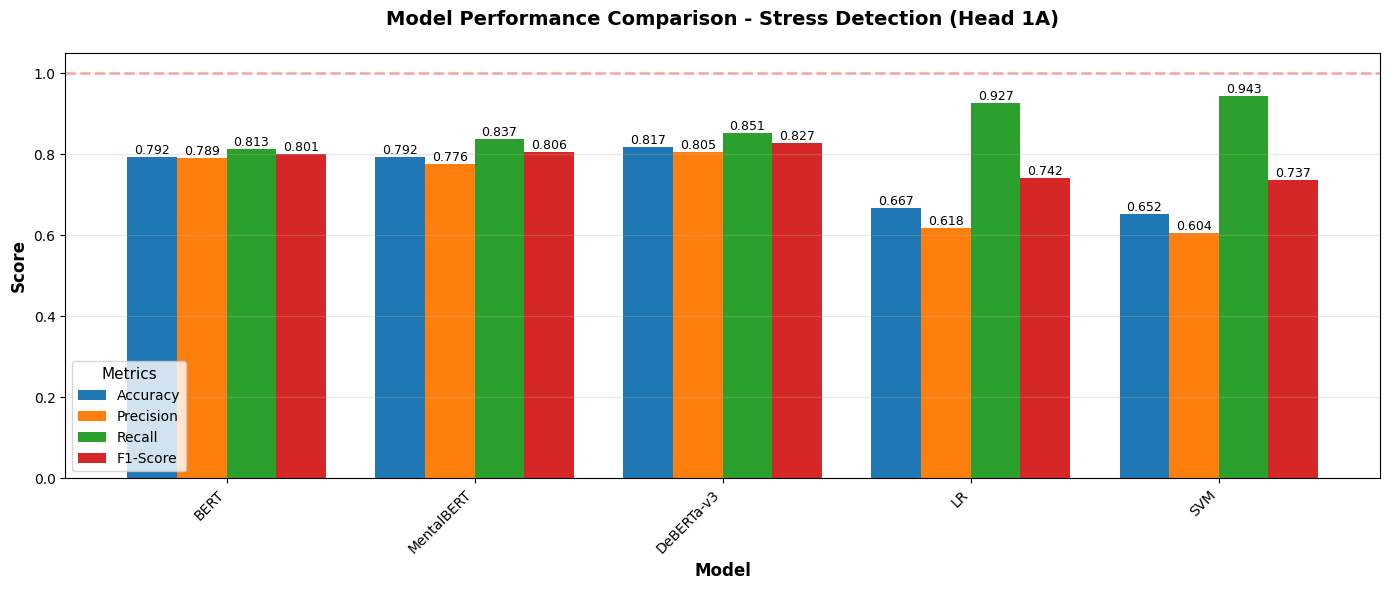

 Saved: 1_metrics_comparison.png


In [23]:
# Metrics Comparison Bar Chart 

# Select metrics to compare
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
plot_df = comparison_df[['Model'] + metrics_to_plot].set_index('Model')

# Create bar chart
fig, ax = plt.subplots(figsize=(14, 6))
plot_df.plot(kind='bar', ax=ax, width=0.8)

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison - Stress Detection (Head 1A)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(title='Metrics', fontsize=10, title_fontsize=11)
ax.set_ylim([0, 1.05])
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, alpha=0.3, label='Perfect')

# Rotate x labels
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS_DIR / '1_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: 1_metrics_comparison.png")

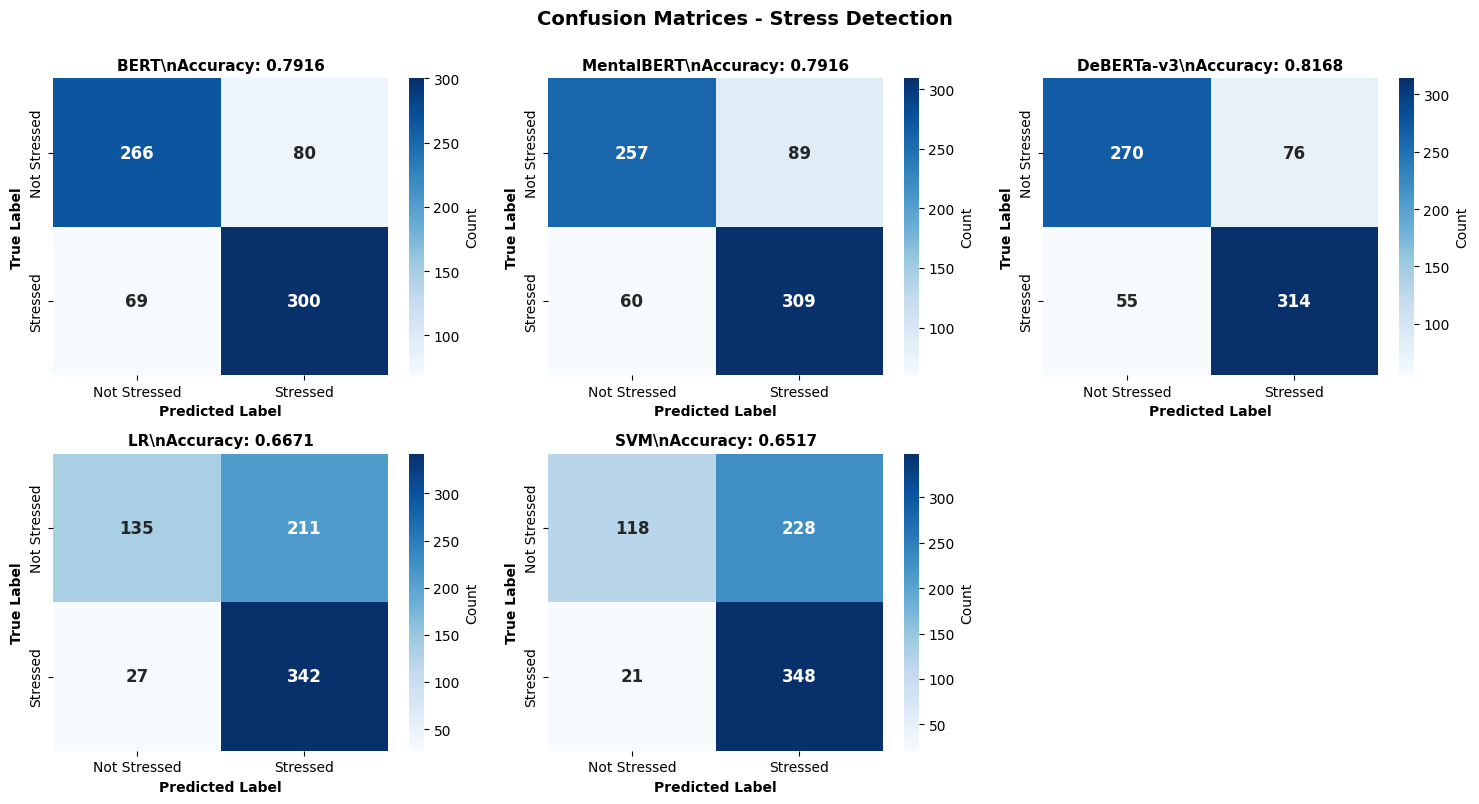

 Saved: 2_confusion_matrices.png


In [24]:
# Confusion Matrices 
n_models = len(all_results)
ncols = min(3, n_models)
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
if n_models == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, (model_name, result) in enumerate(all_results.items()):
    ax = axes[idx]
    
    # Compute confusion matrix
    cm = confusion_matrix(result['labels_stress'], result['preds_stress'])
    
    # Plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=['Not Stressed', 'Stressed'],
                yticklabels=['Not Stressed', 'Stressed'],
                cbar_kws={'label': 'Count'},
                annot_kws={'fontsize': 12, 'fontweight': 'bold'})
    
    ax.set_title(f'{model_name}\\nAccuracy: {result["metrics_stress"]["accuracy"]:.4f}',
                fontsize=11, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10, fontweight='bold')

# Hide unused subplots
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Confusion Matrices - Stress Detection', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '2_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: 2_confusion_matrices.png")

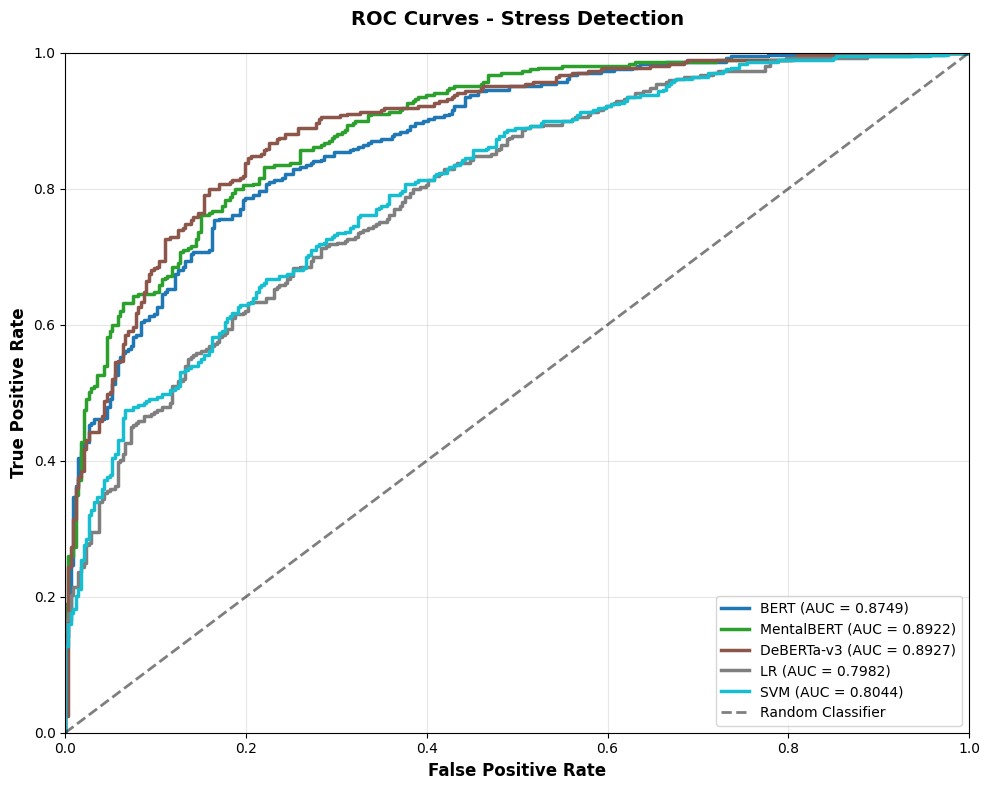

 Saved: 3_roc_curves.png


In [25]:
# ROC Curves 
fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(all_results)))

for color, (model_name, result) in zip(colors, all_results.items()):
    try:
        fpr, tpr, _ = roc_curve(result['labels_stress'], result['probs_stress'])
        roc_auc = auc(fpr, tpr)
        
        ax.plot(fpr, tpr, lw=2.5, label=f'{model_name} (AUC = {roc_auc:.4f})', 
                color=color)
    except Exception as e:
        print(f"   Could not plot ROC for {model_name}: {e}")

# Plot diagonal (random classifier)
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier', alpha=0.5)

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves - Stress Detection', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(PLOTS_DIR / '3_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: 3_roc_curves.png")

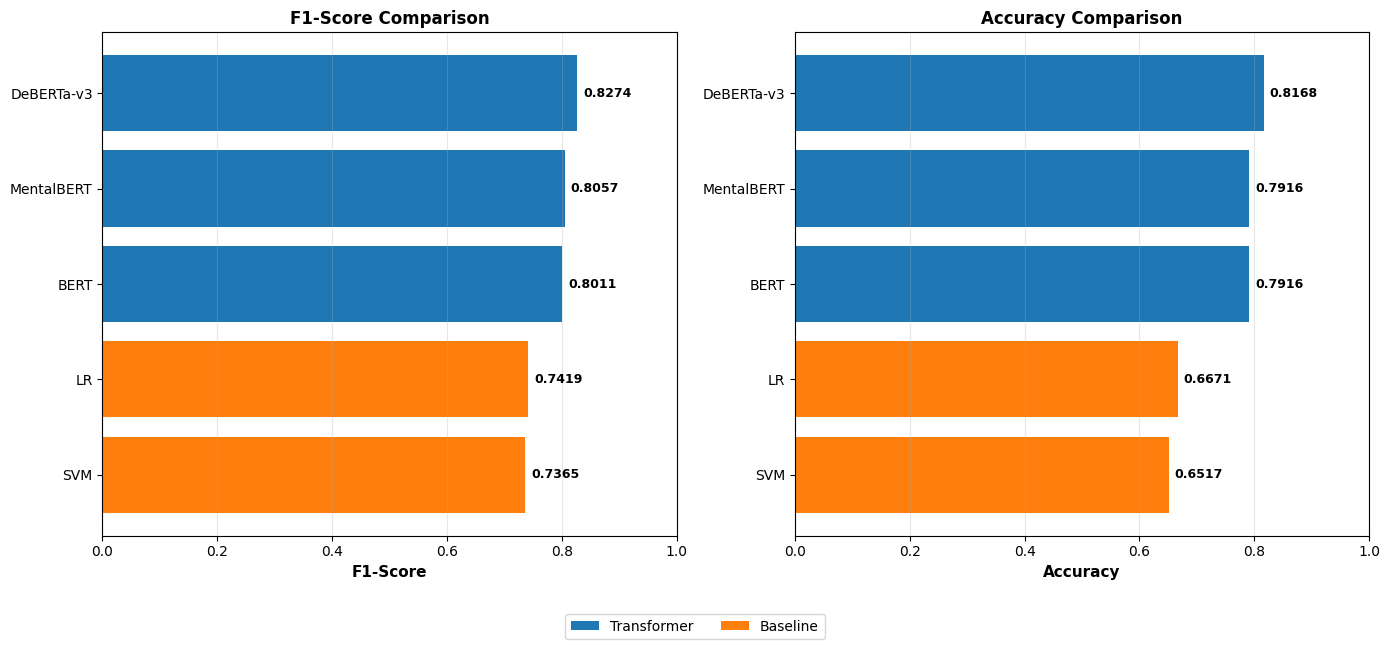

 Saved: 4_f1_accuracy_comparison.png


In [26]:
# F1-Score & Accuracy Comparison 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# F1-Score
f1_data = comparison_df.sort_values('F1-Score', ascending=True)
colors_f1 = ['#ff7f0e' if t == 'Baseline' else '#1f77b4' for t in f1_data['Type']]
ax1.barh(f1_data['Model'], f1_data['F1-Score'], color=colors_f1)
ax1.set_xlabel('F1-Score', fontsize=11, fontweight='bold')
ax1.set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
ax1.set_xlim([0, 1])
ax1.grid(axis='x', alpha=0.3)
for idx, (model, val) in enumerate(zip(f1_data['Model'], f1_data['F1-Score'])):
    ax1.text(val + 0.01, idx, f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

# Accuracy
acc_data = comparison_df.sort_values('Accuracy', ascending=True)
colors_acc = ['#ff7f0e' if t == 'Baseline' else '#1f77b4' for t in acc_data['Type']]
ax2.barh(acc_data['Model'], acc_data['Accuracy'], color=colors_acc)
ax2.set_xlabel('Accuracy', fontsize=11, fontweight='bold')
ax2.set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
ax2.set_xlim([0, 1])
ax2.grid(axis='x', alpha=0.3)
for idx, (model, val) in enumerate(zip(acc_data['Model'], acc_data['Accuracy'])):
    ax2.text(val + 0.01, idx, f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1f77b4', label='Transformer'),
                   Patch(facecolor='#ff7f0e', label='Baseline')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, 
          bbox_to_anchor=(0.5, -0.02), fontsize=10)

plt.tight_layout()
plt.savefig(PLOTS_DIR / '4_f1_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: 4_f1_accuracy_comparison.png")

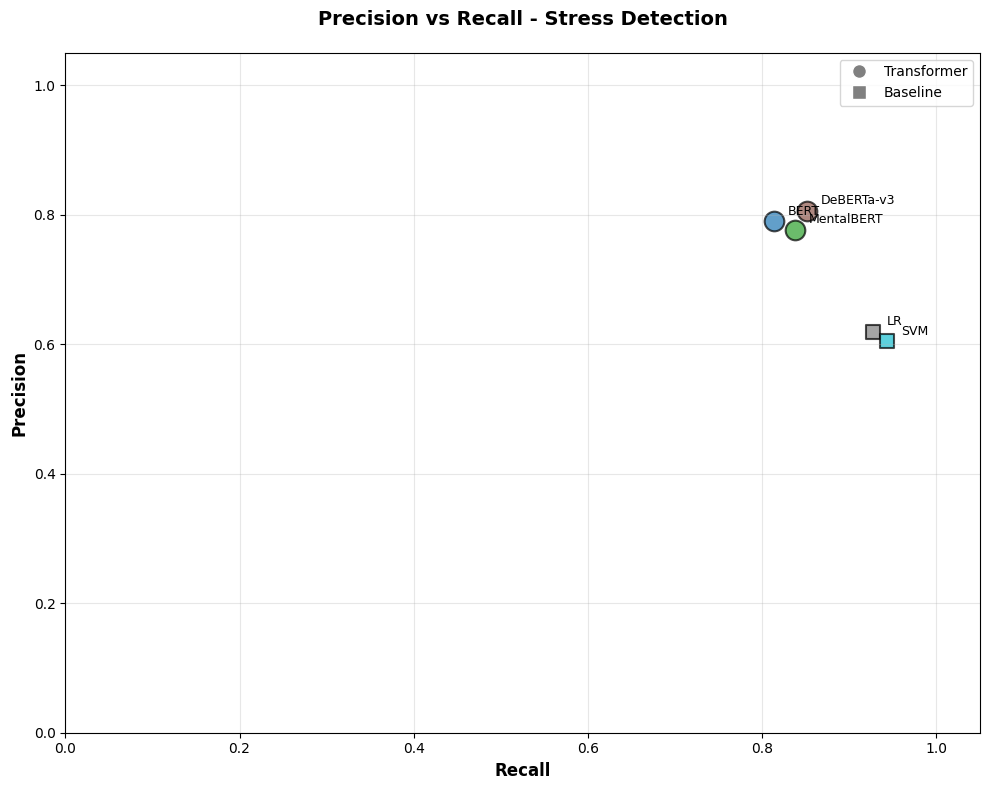

 Saved: 5_precision_recall.png


In [27]:
# Precision vs Recall
fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(all_results)))
sizes = [200 if comparison_df[comparison_df['Model'] == m]['Type'].values[0] == 'Transformer' else 100 
         for m in comparison_df['Model']]
markers = ['o' if comparison_df[comparison_df['Model'] == m]['Type'].values[0] == 'Transformer' else 's' 
           for m in comparison_df['Model']]

for idx, (model_name, color, size, marker) in enumerate(zip(comparison_df['Model'], colors, sizes, markers)):
    precision = comparison_df[comparison_df['Model'] == model_name]['Precision'].values[0]
    recall = comparison_df[comparison_df['Model'] == model_name]['Recall'].values[0]
    ax.scatter(recall, precision, s=size, c=[color], marker=marker, 
              label=model_name, alpha=0.7, edgecolors='black', linewidth=1.5)
    ax.annotate(model_name, (recall, precision), 
               xytext=(10, 5), textcoords='offset points', fontsize=9)

ax.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax.set_title('Precision vs Recall - Stress Detection', fontsize=14, fontweight='bold', pad=20)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1.05])
ax.set_ylim([0, 1.05])

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Transformer'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, label='Baseline')
]
ax.legend(handles=legend_elements, loc='best', fontsize=10)

plt.tight_layout()
plt.savefig(PLOTS_DIR / '5_precision_recall.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: 5_precision_recall.png")

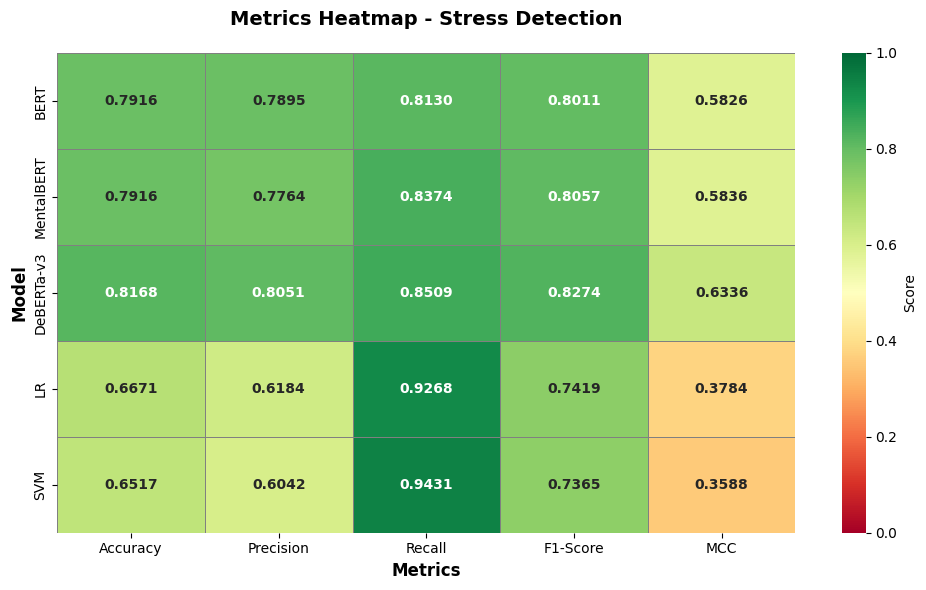

 Saved: 6_metrics_heatmap.png


In [28]:
# Metrics Heatmap
# Prepare data for heatmap
heatmap_data = comparison_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'MCC']].set_index('Model')

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax,
           cbar_kws={'label': 'Score'}, vmin=0, vmax=1,
           linewidths=0.5, linecolor='gray',
           annot_kws={'fontsize': 10, 'fontweight': 'bold'})

ax.set_title('Metrics Heatmap - Stress Detection', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Model', fontsize=12, fontweight='bold')
ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / '6_metrics_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: 6_metrics_heatmap.png")

In [29]:
# Detailed Classification Reports 


detailed_reports = {}

for model_name, result in all_results.items():
    print(f"Model: {model_name} ({result['type']})")

    
    report = classification_report(
        result['labels_stress'], 
        result['preds_stress'],
        target_names=['Not Stressed', 'Stressed'],
        digits=4
    )
    print(report)
    
    detailed_reports[model_name] = report

# Save detailed reports
with open(RESULTS_DIR / 'detailed_classification_reports.txt', 'w') as f:
    for model_name, report in detailed_reports.items():
        f.write(f"\n{'='*70}\n")
        f.write(f"Model: {model_name}\n")
        f.write(f"{'='*70}\n")
        f.write(report)
        f.write('\n')

print("\n Saved detailed reports to: detailed_classification_reports.txt")

Model: BERT (Transformer)
              precision    recall  f1-score   support

Not Stressed     0.7940    0.7688    0.7812       346
    Stressed     0.7895    0.8130    0.8011       369

    accuracy                         0.7916       715
   macro avg     0.7918    0.7909    0.7911       715
weighted avg     0.7917    0.7916    0.7915       715

Model: MentalBERT (Transformer)
              precision    recall  f1-score   support

Not Stressed     0.8107    0.7428    0.7753       346
    Stressed     0.7764    0.8374    0.8057       369

    accuracy                         0.7916       715
   macro avg     0.7936    0.7901    0.7905       715
weighted avg     0.7930    0.7916    0.7910       715

Model: DeBERTa-v3 (Transformer)
              precision    recall  f1-score   support

Not Stressed     0.8308    0.7803    0.8048       346
    Stressed     0.8051    0.8509    0.8274       369

    accuracy                         0.8168       715
   macro avg     0.8179    0.8156    0

In [30]:
# Summary Statistics & Key Findings
print("SUMMARY STATISTICS & KEY FINDINGS")


# Best models for each metric
print("\n BEST MODELS PER METRIC:")

metrics_to_check = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'MCC', 'ROC-AUC']
for metric in metrics_to_check:
    if metric in comparison_df.columns:
        best_idx = comparison_df[metric].idxmax()
        best_model = comparison_df.loc[best_idx, 'Model']
        best_val = comparison_df.loc[best_idx, metric]
        best_type = comparison_df.loc[best_idx, 'Type']
        print(f"  {metric:15s}: {best_model:15s} ({best_type:12s}) = {best_val:.4f}")

# Average metrics by type
print("\n AVERAGE METRICS BY MODEL TYPE:")
print("---------------------------------------------------")

for model_type in comparison_df['Type'].unique():
    type_data = comparison_df[comparison_df['Type'] == model_type]
    avg_acc = type_data['Accuracy'].mean()
    avg_f1 = type_data['F1-Score'].mean()
    avg_prec = type_data['Precision'].mean()
    avg_rec = type_data['Recall'].mean()
    
    print(f"\n  {model_type}:")
    print(f"    Avg Accuracy  : {avg_acc:.4f}")
    print(f"    Avg Precision : {avg_prec:.4f}")
    print(f"    Avg Recall    : {avg_rec:.4f}")
    print(f"    Avg F1-Score  : {avg_f1:.4f}")

# Model rankings
print("\n MODEL RANKINGS (by F1-Score):")
print("---------------------------------------------------")

ranked = comparison_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
for idx, row in ranked.iterrows():
    medal = ['', '', ''][idx] if idx < 3 else f'{idx+1:2d}.'
    print(f"  {medal} {row['Model']:15s} - F1: {row['F1-Score']:.4f}, Acc: {row['Accuracy']:.4f}")

# Save all results to JSON
all_results_json = {}
for model_name, result in all_results.items():
    all_results_json[model_name] = {
        'type': result['type'],
        'stress_detection_metrics': result['metrics_stress'],
    }
    if 'metrics_subreddit' in result:
        all_results_json[model_name]['subreddit_metrics'] = result['metrics_subreddit']

with open(RESULTS_DIR / 'all_evaluation_results.json', 'w') as f:
    json.dump(all_results_json, f, indent=2, default=str)



SUMMARY STATISTICS & KEY FINDINGS

 BEST MODELS PER METRIC:
  Accuracy       : DeBERTa-v3      (Transformer ) = 0.8168
  Precision      : DeBERTa-v3      (Transformer ) = 0.8051
  Recall         : SVM             (Baseline    ) = 0.9431
  F1-Score       : DeBERTa-v3      (Transformer ) = 0.8274
  MCC            : DeBERTa-v3      (Transformer ) = 0.6336
  ROC-AUC        : DeBERTa-v3      (Transformer ) = 0.8927

 AVERAGE METRICS BY MODEL TYPE:
---------------------------------------------------

  Transformer:
    Avg Accuracy  : 0.8000
    Avg Precision : 0.7903
    Avg Recall    : 0.8338
    Avg F1-Score  : 0.8114

  Baseline:
    Avg Accuracy  : 0.6594
    Avg Precision : 0.6113
    Avg Recall    : 0.9350
    Avg F1-Score  : 0.7392

 MODEL RANKINGS (by F1-Score):
---------------------------------------------------
   DeBERTa-v3      - F1: 0.8274, Acc: 0.8168
   MentalBERT      - F1: 0.8057, Acc: 0.7916
   BERT            - F1: 0.8011, Acc: 0.7916
   4. LR              - F1: 0.7419, A